In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('customers.csv')
df.head()

,FirstName,LastName,Email,Phone,City,Country,Gender,RegistrationDate
0,Mark,Johnson,mark.johnson@yahoo.com,232.318.1960,East William,Anguilla,Male,2026-01-26
1,Cristian,Santos,cristian.santos@hotmail.com,(337)894-0265x42351,West Melanieview,Sri Lanka,Male,2023-11-14
2,Monica,Herrera,monica.herrera@yahoo.com,584-695-9310,Port Jesseville,Hong Kong,Female,2024-11-12
3,Jesse,Flowers,jesse.flowers@gmail.com,(653)541-9283x276,Meganton,Denmark,Male,2023-10-27
4,Robert,Morales,robert.morales@gmail.com,495.537.6724,Juliechester,Ukraine,Male,2026-03-02


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   FirstName         2000 non-null   object
 1   LastName          2000 non-null   object
 2   Email             2000 non-null   object
 3   Phone             2000 non-null   object
 4   City              2000 non-null   object
 5   Country           2000 non-null   object
 6   Gender            2000 non-null   object
 7   RegistrationDate  2000 non-null   object
dtypes: object(8)
memory usage: 125.1+ KB


In [4]:
df.shape[0]

2000

In [5]:
df['Phone'].head(10)

0           232.318.1960
1    (337)894-0265x42351
2           584-695-9310
3      (653)541-9283x276
4           495.537.6724
5     671.201.2269x16697
6       704.482.8148x932
7           403.491.1718
8        +1-534-565-7871
9             9315051834
Name: Phone, dtype: object

In [6]:
# 1. إزالة التحويلات (مثل x123) والرموز غير الرقمية، ثم التحويل إلى int64
df['Phone'] = (
    df['Phone']
    .astype(str)
    .str.split('x').str[0]              # التخلص من الـ Extension مثل x42351
    .str.replace(r'\D+', '', regex=True) # حذف أي رمز ليس رقماً (- . ( ) +)
    .astype('int64')                    # التحويل إلى رقم صحيح
)

# 2. معاينة النتيجة ونوع البيانات
print(df[['FirstName', 'Phone']].head())
print("\nنوع البيانات الجديد:", df['Phone'].dtype)


  FirstName       Phone
0      Mark  2323181960
1  Cristian  3378940265
2    Monica  5846959310
3     Jesse  6535419283
4    Robert  4955376724

نوع البيانات الجديد: int64


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   FirstName         2000 non-null   object
 1   LastName          2000 non-null   object
 2   Email             2000 non-null   object
 3   Phone             2000 non-null   int64 
 4   City              2000 non-null   object
 5   Country           2000 non-null   object
 6   Gender            2000 non-null   object
 7   RegistrationDate  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [8]:
df['RegistrationDate'] = pd.to_datetime(df['RegistrationDate'])

In [9]:
df['RegistrationDate'].dtype

dtype('<M8[ns]')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   FirstName         2000 non-null   object        
 1   LastName          2000 non-null   object        
 2   Email             2000 non-null   object        
 3   Phone             2000 non-null   int64         
 4   City              2000 non-null   object        
 5   Country           2000 non-null   object        
 6   Gender            2000 non-null   object        
 7   RegistrationDate  2000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 125.1+ KB


In [11]:
# 1. دمج الاسم الأول والأخير لإنشاء الاسم الكامل
df['FullName'] = df['FirstName'] + ' ' + df['LastName']

# 2. استخراج نطاق الإيميل (Email Provider) مثل gmail, yahoo, hotmail
df['EmailDomain'] = df['Email'].str.split('@').str[1]

# 3. استخراج خصائص زمنية من تاريخ التسجيل
df['Reg_Year'] = df['RegistrationDate'].dt.year
df['Reg_Month'] = df['RegistrationDate'].dt.month_name()
df['Reg_DayName'] = df['RegistrationDate'].dt.day_name()
df['Reg_Quarter'] = 'Q' + df['RegistrationDate'].dt.quarter.astype(str)

# 4. حساب مدة بقاء العميل بالأيام (Customer Tenure in Days)
df['Tenure_Days'] = (pd.to_datetime('today') - df['RegistrationDate']).dt.days

# معاينة الأعمدة الجديدة
df[['FullName', 'EmailDomain', 'Reg_Year', 'Reg_Month', 'Reg_DayName', 'Tenure_Days']].head()


,FullName,EmailDomain,Reg_Year,Reg_Month,Reg_DayName,Tenure_Days
0,Mark Johnson,yahoo.com,2026,January,Monday,225
1,Cristian Santos,hotmail.com,2023,November,Tuesday,1029
2,Monica Herrera,yahoo.com,2024,November,Tuesday,665
3,Jesse Flowers,gmail.com,2023,October,Friday,1047
4,Robert Morales,gmail.com,2026,March,Monday,190


C:\Users\Omar\AppData\Local\Temp\ipykernel_17920\329352284.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', palette=['#3498db', '#e74c3c'])


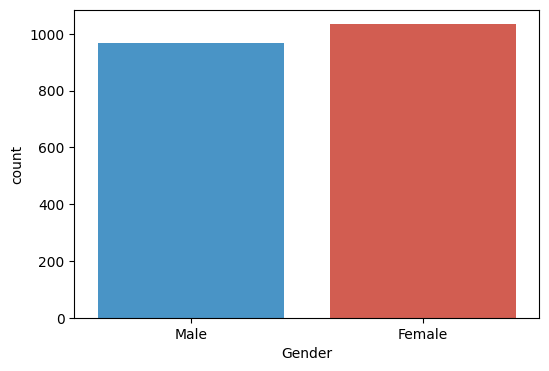

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender', palette=['#3498db', '#e74c3c'])
plt.show()


C:\Users\Omar\AppData\Local\Temp\ipykernel_17920\1207268748.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='crest')


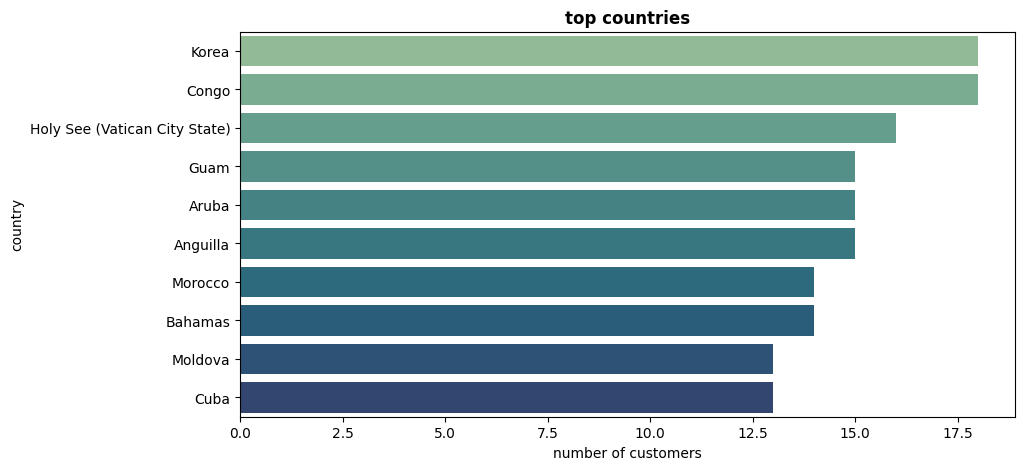

In [14]:
plt.figure(figsize=(10, 5))
top_countries = df['Country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='crest')
plt.title('top countries', fontweight='bold')
plt.xlabel('number of customers')
plt.ylabel('country')
plt.show()

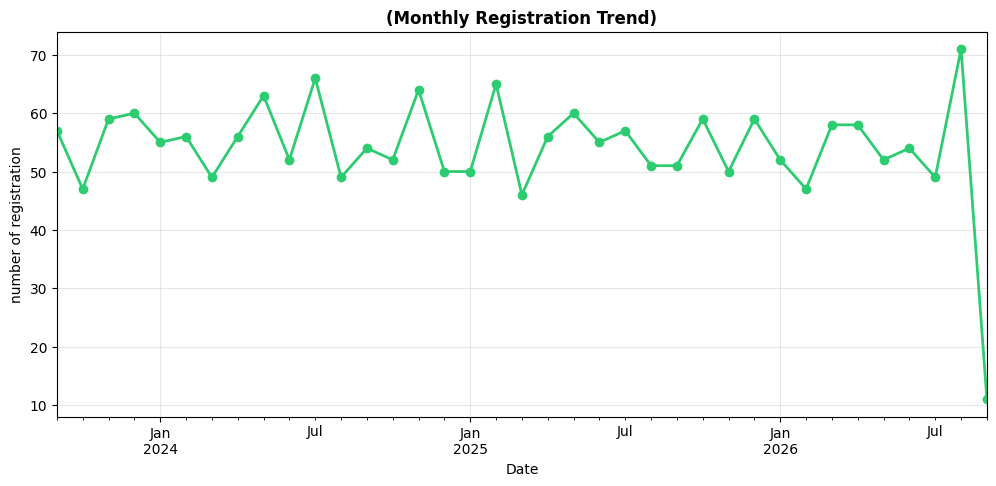

In [15]:
plt.figure(figsize=(12, 5))
monthly_reg = df.set_index('RegistrationDate').resample('ME').size()
monthly_reg.plot(color='#2ecc71', marker='o', linewidth=2)
plt.title('(Monthly Registration Trend)', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('number of registration')
plt.grid(True, alpha=0.3)
plt.show()


C:\Users\Omar\AppData\Local\Temp\ipykernel_17920\3812341924.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='EmailDomain', palette='viridis', order=df['EmailDomain'].value_counts().index)


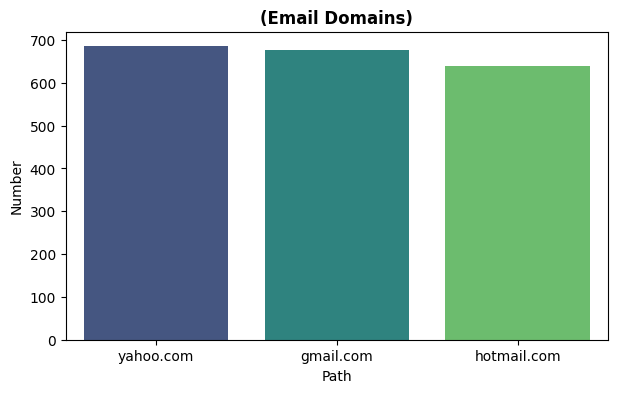

In [16]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='EmailDomain', palette='viridis', order=df['EmailDomain'].value_counts().index)
plt.title('(Email Domains)', fontweight='bold')
plt.xlabel('Path')
plt.ylabel('Number')
plt.show()


C:\Users\Omar\AppData\Local\Temp\ipykernel_17920\2286395162.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Reg_DayName', order=days_order, palette='Set2')


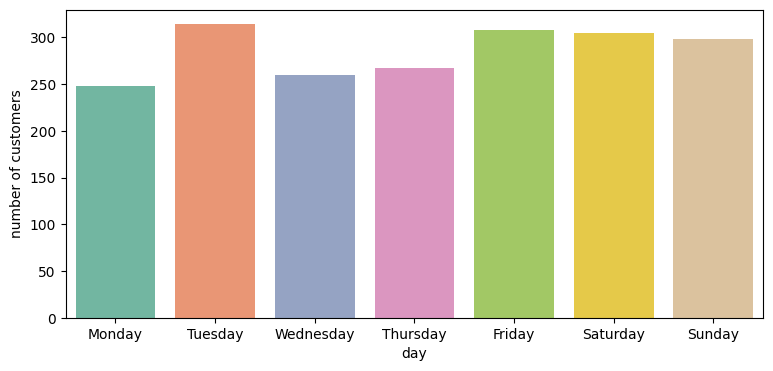

In [17]:
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x='Reg_DayName', order=days_order, palette='Set2')
plt.xlabel('day')
plt.ylabel('number of customers')
plt.show()


In [18]:
df.to_csv('customers_cleaned.csv', index=False)
print("تم حفظ الداتا سيت المنظفة ")


تم حفظ الداتا سيت المنظفة 


In [19]:
import urllib
from sqlalchemy import create_engine

# 1. إعداد الاتصال بسيرفر SQL Server
# اسم السيرفر لديك من الصورة هو: localhost
connection_string = (
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=Ecommerce;"
    "Trusted_Connection=yes;"
)

params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

# 2. رفع البيانات داخل جدول Customers الموجود
df.to_sql('Customers', con=engine, if_exists='append', index=False)
print("✅ تم رفع 2000 عميل داخل جدول Customers بنجاح!")


C:\Users\Omar\AppData\Roaming\Python\Python311\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


✅ تم رفع 2000 عميل داخل جدول Customers بنجاح!
